# Physics-Informed Hybrid Observables on Directional Advection

This notebook demonstrates hybrid physics-informed observables on directional
grid advection with three models that share the **same total** ``latent_dim``.
It assumes the encode → Koopman step → decode workflow from
[`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) and the directional grid
setup from [`04_grid_attention.ipynb`](04_grid_attention.ipynb); here the focus
is prepending physics features before the learned latent state.

1. **Pure GNN** — learned lifting only (full width is GNN).
2. **Laplacian preset hybrid** — prepends ``L_norm @ x`` via
   ``physics_preset='graph_laplacian'``.
3. **Custom hybrid** — prepends west/north neighbor states via a user-defined
   ``physics_lifting_fn``.

The Laplacian preset prepends features from $L_{\mathrm{sym}} = P - \widehat{A}$
(isolate-aware symmetric normalized Laplacian).

The benchmark is ``AnisotropicAdvectionGridBenchmark``, where node features evolve
through **asymmetric** weighted neighbor mixing (west/north directions dominate)
with self-retention — advection-like dynamics on a grid, not exact symmetric
Laplacian diffusion. A custom directional lift is **motivated by** that update
rule; a Laplacian preset instead injects a **symmetric** structural prior. Which
prior helps is seed- and horizon-dependent — do not assume directional features
must win.

**Evaluation protocol / scope.** Primary goal is the API/contract (presets,
custom callables, ``save``/``load``). Held-out RMSE is a **cautionary
matched-capacity**, single-seed illustration — not a general hybrid-vs-GNN
benchmark claim.


## Method: hybrid physics lifting

Physics features are prepended to the GNN latent:

``z = [z_physics || z_gnn]``

Supply either a built-in preset (``physics_preset='graph_laplacian'``) or a custom
callable ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)``
features. Set ``physics_dim`` explicitly and ensure
``latent_dim = physics_dim + encoder.latent_dim``. For a fair width comparison,
fix a shared ``TOTAL_LATENT`` and set
``encoder.latent_dim = TOTAL_LATENT - physics_dim`` (pure GNN uses
``physics_dim = 0``). Custom callables are not serialized — re-supply
``physics_lifting_fn`` on ``GraphKoopmanModel.load``.


In [1]:
import os
import tempfile
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import torch
from torch_geometric.data import Data
from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

if os.environ.get("PYTEST_CURRENT_TEST"):
    matplotlib.use("Agg")

try:
    from IPython import get_ipython

    if get_ipython() is not None and not os.environ.get("PYTEST_CURRENT_TEST"):
        get_ipython().run_line_magic("matplotlib", "inline")
except (ImportError, NameError):
    pass

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import temporal_split
from koopman_graph.datasets import AnisotropicAdvectionGridBenchmark
from koopman_graph.losses import PDEResidualLoss
from koopman_graph.observables import (
    graph_curvature_features,
    graph_gradient_features,
    graph_laplacian_features,
    resolve_physics_lifting_fn,
)
from koopman_graph.training import ExtraLosses, LossWeights

# Notebook-level seeds, data dims, and matched-capacity hyperparameters.
DATA_SEED = 0
MODEL_SEED = 1

IS_CI = bool(os.environ.get("PYTEST_CURRENT_TEST"))
NUM_TIMESTEPS = 40 if IS_CI else 100
NUM_ROWS = 4 if IS_CI else 8
NUM_COLS = 4 if IS_CI else 8
IN_CHANNELS = 3
# Shared total latent width (matched capacity across pure / hybrid models).
# Anchor on the Laplacian hybrid's natural split (physics_dim = in_channels,
# GNN remainder = 16) so all three models share latent_dim = 19.
CUSTOM_PHYSICS_DIM = 2 * IN_CHANNELS  # west + north neighbor states
LAPLACIAN_PHYSICS_DIM = IN_CHANNELS  # L_norm @ x
GNN_REMAINDER_FOR_LAPLACIAN = 16
TOTAL_LATENT = GNN_REMAINDER_FOR_LAPLACIAN + LAPLACIAN_PHYSICS_DIM  # 19
HIDDEN = 32
TIME_STEP = 0.1
EPOCHS = 8 if IS_CI else 50
LR = 5e-3
# Short CI horizons keep evaluate() within the truncated test split.
EVAL_HORIZONS = [2, 3] if IS_CI else [3, 6, 12]
# Dense open-loop curve (avoids sparse-bar artifacts such as apparent flatness).
RMSE_CURVE_HORIZONS = list(range(1, 4)) if IS_CI else list(range(1, 13))


## Helper functions

Physics lifting, model builders, and residual helpers used below.


In [2]:
def directional_advection_features(data: Data) -> torch.Tensor:
    """West- and north-neighbor states for hybrid lifting.

    Boundary nodes without a west/north neighbor copy their own state.
    Absolute neighbor values are stabler long-horizon physics coordinates
    than raw deltas ``x_neighbor - x``, which shrink as the field smooths
    and are easy for unconstrained ``K`` to amplify in open-loop rollout.
    """
    x = data.x
    west = torch.empty_like(x)
    north = torch.empty_like(x)
    for row in range(NUM_ROWS):
        for col in range(NUM_COLS):
            node = row * NUM_COLS + col
            if col > 0:
                west[node] = x[row * NUM_COLS + (col - 1)]
            else:
                west[node] = x[node]
            if row > 0:
                north[node] = x[(row - 1) * NUM_COLS + col]
            else:
                north[node] = x[node]
    return torch.cat([west, north], dim=-1)

def build_model(
    *,
    physics_dim: int,
    physics_preset: str | None = None,
    physics_lifting_fn=None,
) -> GraphKoopmanModel:
    gnn_latent_dim = TOTAL_LATENT - physics_dim
    return GraphKoopmanModel(
        encoder=GNNEncoder(
            in_channels=IN_CHANNELS,
            hidden_channels=HIDDEN,
            latent_dim=gnn_latent_dim,
        ),
        decoder=GNNDecoder(
            latent_dim=TOTAL_LATENT,
            hidden_channels=HIDDEN,
            out_channels=IN_CHANNELS,
        ),
        latent_dim=TOTAL_LATENT,
        time_step=TIME_STEP,
        physics_preset=physics_preset,
        physics_lifting_fn=physics_lifting_fn,
        physics_dim=physics_dim,
    )

def spatial_smoothness_residual(
    decoded: torch.Tensor,
    snapshot: Data,
) -> torch.Tensor:
    context = snapshot.clone()
    context.x = decoded
    return graph_laplacian_features(context)


## Generate advection grid data

Train / validation / test split on directional advection. Shared capacity
comparisons use the fixed ``TOTAL_LATENT`` from the setup cell.


In [3]:
torch.manual_seed(DATA_SEED)
sequence = AnisotropicAdvectionGridBenchmark.generate(
    num_rows=NUM_ROWS,
    num_cols=NUM_COLS,
    num_timesteps=NUM_TIMESTEPS,
    in_channels=IN_CHANNELS,
    seed=DATA_SEED,
)
split = temporal_split(
    sequence,
    train_ratio=0.6,
    val_ratio=0.15,
    test_ratio=0.25,
)

print(
    f"nodes={sequence.num_nodes}, "
    f"train={split.train.num_timesteps}, "
    f"val={split.val.num_timesteps}, "
    f"test={split.test.num_timesteps}"
)
print(
    f"TOTAL_LATENT={TOTAL_LATENT} "
    f"(Laplacian physics_dim={LAPLACIAN_PHYSICS_DIM}, "
    f"custom physics_dim={CUSTOM_PHYSICS_DIM})"
)


nodes=64, train=60, val=15, test=25
TOTAL_LATENT=19 (Laplacian physics_dim=3, custom physics_dim=6)


## Custom physics lifting function

West/north neighbor states as a directional prior (``physics_dim = 2 * in_channels``).
The callable itself lives in **Helper functions** above; this cell only confirms dimensions.


In [4]:
print("Using directional_advection_features (defined in Helper functions).")
print(f"Custom physics_dim will be {2 * IN_CHANNELS} (west + north).")


Using directional_advection_features (defined in Helper functions).
Custom physics_dim will be 6 (west + north).


## Train

Pure GNN vs Laplacian-preset hybrid vs custom hybrid — matched total latent width.


In [5]:
torch.manual_seed(MODEL_SEED)
pure_model = build_model(physics_dim=0)

torch.manual_seed(MODEL_SEED)
laplacian_model = build_model(
    physics_dim=LAPLACIAN_PHYSICS_DIM,
    physics_preset="graph_laplacian",
)

torch.manual_seed(MODEL_SEED)
custom_model = build_model(
    physics_dim=CUSTOM_PHYSICS_DIM,
    physics_lifting_fn=directional_advection_features,
)

assert (
    pure_model.latent_dim
    == laplacian_model.latent_dim
    == custom_model.latent_dim
    == TOTAL_LATENT
)
print(
    f"Matched total latent_dim={TOTAL_LATENT}; "
    f"pure gnn={pure_model.gnn_latent_dim}; "
    f"Laplacian hybrid gnn={laplacian_model.gnn_latent_dim} "
    f"+ physics={laplacian_model.physics_dim}; "
    f"custom hybrid gnn={custom_model.gnn_latent_dim} "
    f"+ physics={custom_model.physics_dim}"
)

pure_history = pure_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
laplacian_history = laplacian_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)
custom_history = custom_model.fit(
    split.train,
    validation_sequence=split.val,
    epochs=EPOCHS,
    lr=LR,
)

print(f"Pure GNN final val loss:      {pure_history.val_loss[-1]:.6f}")
print(f"Laplacian hybrid val loss:    {laplacian_history.val_loss[-1]:.6f}")
print(f"Custom directional val loss:  {custom_history.val_loss[-1]:.6f}")


Matched total latent_dim=19; pure gnn=19; Laplacian hybrid gnn=16 + physics=3; custom hybrid gnn=13 + physics=6


Pure GNN final val loss:      0.003310
Laplacian hybrid val loss:    0.002593
Custom directional val loss:  0.003276


## Evaluate: validation loss and rollout comparison

One-step validation loss can look similar across models while open-loop RMSE
diverges with horizon. The right panel plots RMSE versus every forecast step
as a single-seed cautionary illustration — not a method ranking.

Open-loop RMSE **can** be non-monotone in horizon when a rollout overshoots
and re-crosses the truth. The plot below annotates a Laplacian-hybrid dip
**only if** an interior local minimum appears on this seed.


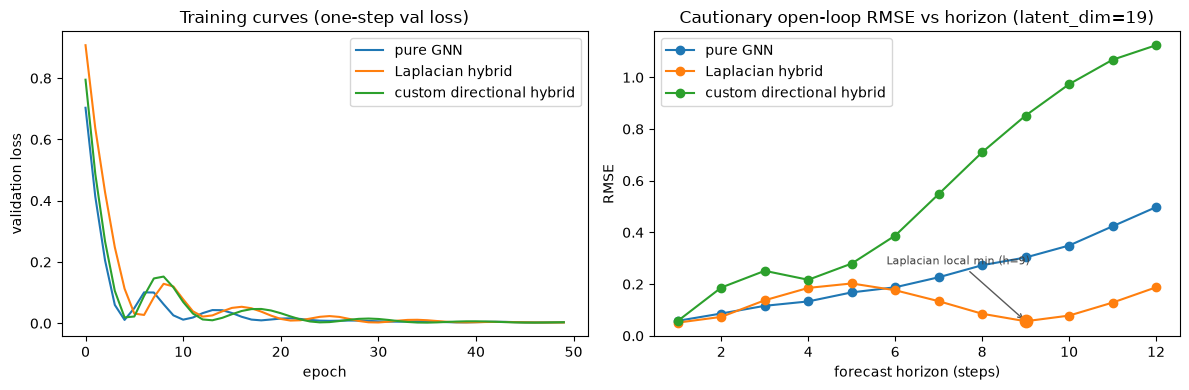

Note: open-loop RMSE can be non-monotone; Laplacian interior dip at h=9.
Cautionary matched-capacity horizon RMSE (pure / Laplacian / custom; total latent_dim=19):
  h= 3: 0.116083 / 0.137501 / 0.251425
  h= 6: 0.187833 / 0.176280 / 0.387859
  h=12: 0.497848 / 0.187716 / 1.124227


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(pure_history.val_loss, label="pure GNN")
axes[0].plot(laplacian_history.val_loss, label="Laplacian hybrid")
axes[0].plot(custom_history.val_loss, label="custom directional hybrid")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("validation loss")
axes[0].set_title("Training curves (one-step val loss)")
axes[0].legend()

pure_eval = pure_model.evaluate(split.test, horizons=RMSE_CURVE_HORIZONS)
laplacian_eval = laplacian_model.evaluate(split.test, horizons=RMSE_CURVE_HORIZONS)
custom_eval = custom_model.evaluate(split.test, horizons=RMSE_CURVE_HORIZONS)

pure_by_h = {metric.horizon: metric for metric in pure_eval.horizons}
laplacian_by_h = {metric.horizon: metric for metric in laplacian_eval.horizons}
custom_by_h = {metric.horizon: metric for metric in custom_eval.horizons}
pure_rmse = [pure_by_h[h].rmse for h in RMSE_CURVE_HORIZONS]
laplacian_rmse = [laplacian_by_h[h].rmse for h in RMSE_CURVE_HORIZONS]
custom_rmse = [custom_by_h[h].rmse for h in RMSE_CURVE_HORIZONS]

axes[1].plot(RMSE_CURVE_HORIZONS, pure_rmse, marker="o", label="pure GNN")
axes[1].plot(RMSE_CURVE_HORIZONS, laplacian_rmse, marker="o", label="Laplacian hybrid")
axes[1].plot(
    RMSE_CURVE_HORIZONS,
    custom_rmse,
    marker="o",
    label="custom directional hybrid",
)
axes[1].set_xlabel("forecast horizon (steps)")
axes[1].set_ylabel("RMSE")
axes[1].set_title(f"Cautionary open-loop RMSE vs horizon (latent_dim={TOTAL_LATENT})")
axes[1].legend()

# Annotate an interior local minimum on the Laplacian curve only when present
# (value strictly below both neighbors). Skip if the curve is monotone.
_dip_h = None
for i in range(1, len(RMSE_CURVE_HORIZONS) - 1):
    left, mid, right = laplacian_rmse[i - 1], laplacian_rmse[i], laplacian_rmse[i + 1]
    if mid < left and mid < right:
        _dip_h = RMSE_CURVE_HORIZONS[i]
        break
if _dip_h is not None:
    axes[1].scatter(
        [_dip_h],
        [laplacian_by_h[_dip_h].rmse],
        color="C1",
        s=80,
        zorder=5,
    )
    axes[1].annotate(
        f"Laplacian local min (h={_dip_h})",
        xy=(_dip_h, laplacian_by_h[_dip_h].rmse),
        xytext=(_dip_h - 3.2, laplacian_by_h[_dip_h].rmse + 0.22),
        fontsize=8,
        arrowprops={"arrowstyle": "->", "color": "0.35"},
        color="0.25",
    )

fig.tight_layout()
plt.show()

if _dip_h is not None:
    print(
        f"Note: open-loop RMSE can be non-monotone; Laplacian interior dip at h={_dip_h}."
    )
else:
    print(
        "Note: open-loop RMSE can be non-monotone in general; "
        "no Laplacian interior dip on this seed."
    )
print(
    f"Cautionary matched-capacity horizon RMSE "
    f"(pure / Laplacian / custom; total latent_dim={TOTAL_LATENT}):"
)
for horizon in EVAL_HORIZONS:
    pure = pure_by_h[horizon].rmse
    laplacian = laplacian_by_h[horizon].rmse
    custom = custom_by_h[horizon].rmse
    print(
        f"  h={horizon:2d}: {pure:.6f} / {laplacian:.6f} / {custom:.6f}"
    )


## Save and reload with a custom ``physics_lifting_fn``

Checkpoints store ``physics_dim`` and optional ``physics_preset``; re-supply
custom callables on load.


In [7]:
initial = split.test[0]
steps = 3
before_save = custom_model.predict(initial, steps=steps)

with tempfile.TemporaryDirectory() as tmpdir:
    checkpoint_path = Path(tmpdir) / "custom_directional_hybrid.pt"
    custom_model.save(checkpoint_path)
    loaded_custom = GraphKoopmanModel.load(
        checkpoint_path,
        physics_lifting_fn=directional_advection_features,
    )

after_load = loaded_custom.predict(initial, steps=steps)
max_diff = max(
    (before.x - after.x).abs().max().item()
    for before, after in zip(before_save, after_load, strict=True)
)
print(f"Loaded physics_dim={loaded_custom.physics_dim} (preset={loaded_custom.physics_preset})")
print(f"Max |x_before - x_after_load| over {steps} steps: {max_diff:.2e}")
assert max_diff < 1e-5, "save/load round-trip predictions should match"
print("save/load round-trip OK")

Loaded physics_dim=6 (preset=None)
Max |x_before - x_after_load| over 3 steps: 0.00e+00
save/load round-trip OK


## Physics presets and decoded-field residual

Optional ``PDEResidualLoss`` on the decoded field, plus notes on built-in presets.
The residual below is an **illustrative Laplacian smoothness** penalty on the
decoded field — not the anisotropic advection update itself.


In [8]:
residual_snapshot = split.test[1]
with torch.no_grad():
    decoded_next = custom_model(split.test[0])

residual_value = PDEResidualLoss()(
    decoded_next,
    residual_snapshot,
    pde_fn=spatial_smoothness_residual,
)

preset_shapes = {
    "graph_gradient": tuple(graph_gradient_features(residual_snapshot).shape),
    "graph_curvature": tuple(graph_curvature_features(residual_snapshot).shape),
    "polynomial(3)": tuple(
        resolve_physics_lifting_fn(physics_preset="polynomial(3)")(
            residual_snapshot
        ).shape
    ),
}
print("preset output shapes:", preset_shapes)
print("illustrative spatial residual:", float(residual_value))

# Training opt-in (shown without retraining this already-fitted comparison):
physics_weights = LossWeights(pde=0.05)
physics_terms = ExtraLosses(pde_residual_fn=spatial_smoothness_residual)
print(
    "fit-time residual configuration:",
    f"LossWeights(pde={physics_weights.pde})",
    "ExtraLosses(pde_residual_fn=spatial_smoothness_residual)",
)


preset output shapes: {'graph_gradient': (64, 3), 'graph_curvature': (64, 3), 'polynomial(3)': (64, 9)}
illustrative spatial residual: 0.0005796049372293055
fit-time residual configuration: LossWeights(pde=0.05) ExtraLosses(pde_residual_fn=spatial_smoothness_residual)


## Takeaways

- **Hybrid lifting:** Concatenates structural and learned features:
  ``z = [z_physics || GNN(x)]``. Use a built-in preset
  (``physics_preset='graph_laplacian'``) or a custom
  ``physics_lifting_fn(data)`` returning ``(num_nodes, physics_dim)`` tensors.
- **Custom example:** ``directional_advection_features`` injects west/north
  neighbor **states** (``physics_dim = 2 * in_channels``), a prior *motivated by*
  directional advection — not a guarantee of better forecasts.
- **API:** Set ``physics_dim`` explicitly;
  ``latent_dim = physics_dim + encoder.latent_dim``. Checkpoints store
  ``physics_dim`` and optional ``physics_preset``; **re-supply custom callables**
  on ``GraphKoopmanModel.load``.
- **Claim supported here / caution:** All models share ``TOTAL_LATENT`` and can
  reach similar one-step val loss, but matched-capacity open-loop RMSE can reverse
  under other seeds or horizons (this notebook shows one seed). Do not read the
  RMSE-vs-horizon curve as a general hybrid-vs-GNN ranking.
- **Figures:** Validation curves and open-loop RMSE-vs-horizon plots illustrate
  this single-seed run. Open-loop RMSE can be **non-monotone** in horizon when a
  rollout overshoots and re-crosses the truth; this notebook annotates a dip
  only when an interior local minimum appears. Prefer multi-seed studies before
  claiming method-level gains.

## Next steps

- See [`04_grid_attention.ipynb`](04_grid_attention.ipynb) for GAT on asymmetric neighbor influence.
- See [`01_synthetic_graph.ipynb`](01_synthetic_graph.ipynb) for the base train/predict workflow.
- See [`08_loss_stability.ipynb`](08_loss_stability.ipynb) for spectral constraints on dense ``K``.
- Explore the [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html).
